# Assignment-9

### Setup & Data Loading

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay



### Exploratory Data Analysis (EDA)

Target Variable Distribution:
 y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


C:\Users\ArunKumar K\AppData\Local\Temp\ipykernel_18636\1176279410.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='Set2')


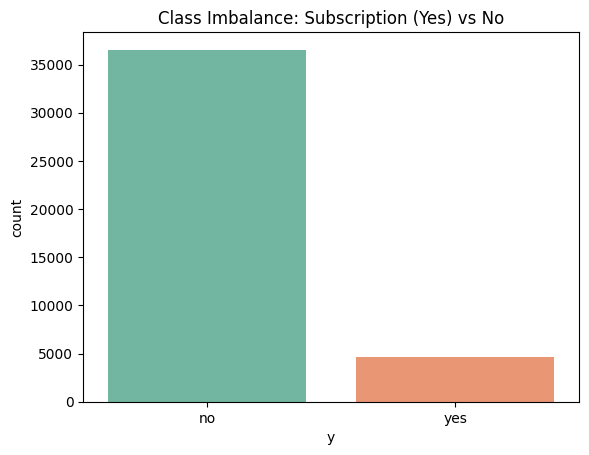

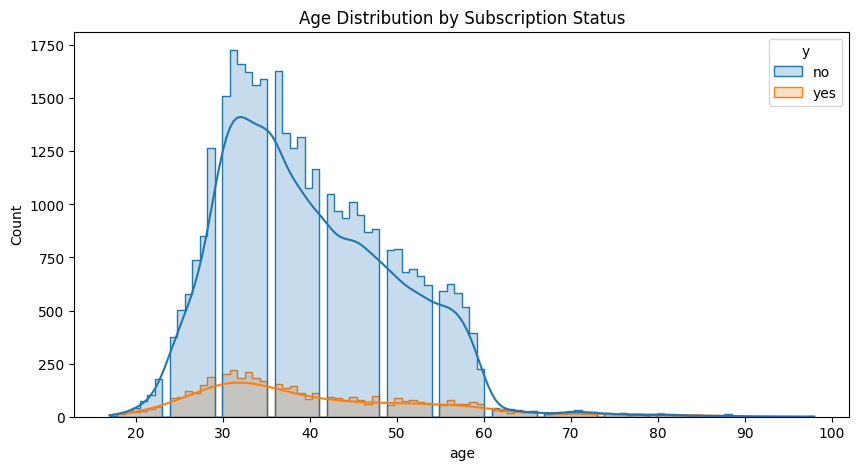

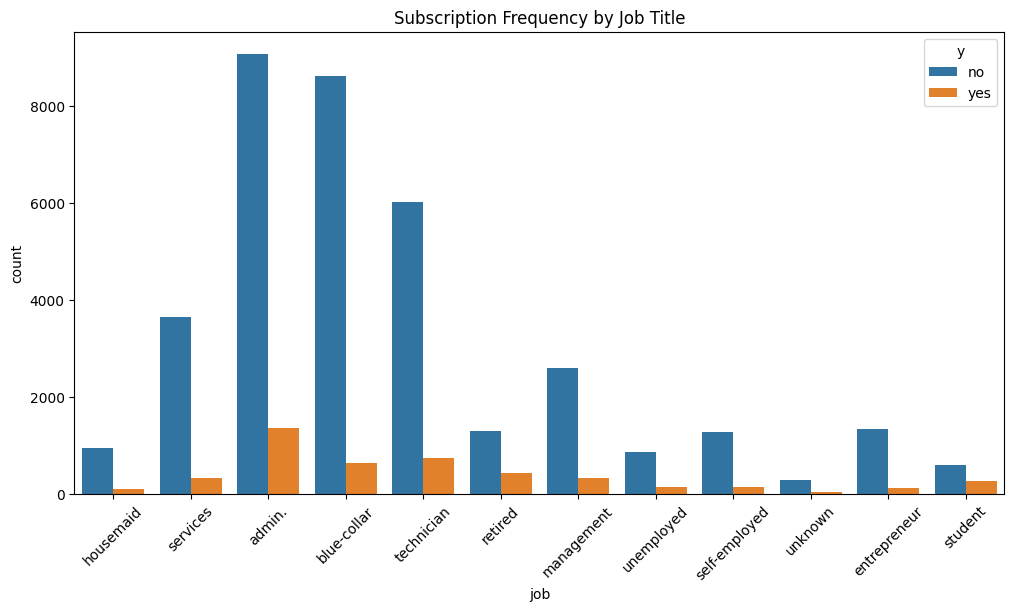

In [ ]:
df = pd.read_csv('D:/Softwares/Git/Assigenment resources/Assigenment 9/bank-marketing-dataset-full.csv', sep=';')

# A. Target Distribution & Class Imbalance
print("Target Variable Distribution:\n", df['y'].value_counts(normalize=True))
sns.countplot(x='y', data=df, palette='Set2')
plt.title('Class Imbalance: Subscription (Yes) vs No')
plt.show()

# B. Numerical Relationships (Example: Age vs Subscription)
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='age', hue='y', kde=True, element='step')
plt.title('Age Distribution by Subscription Status')
plt.show()

# C. Categorical Relationships (Example: Job vs Subscription)
plt.figure(figsize=(12,6))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title('Subscription Frequency by Job Title')
plt.show()

### Preprocessing & Handling Class Imbalance

In [3]:
X = df.drop(['y', 'duration'], axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

# B. Handling Categorical & Numerical Features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# C. Handling Class Imbalance via Stratified Split
# This ensures training and testing sets have the same ratio of 'yes' and 'no'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Classification Modeling

In [4]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# B. Decision Tree
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# C. Ensemble (Random Forest)
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

# Training
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Model Evaluation

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238

ROC-AUC Score: 0.8009

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      7310
           1       0.32      0.32      0.32       928

    accuracy                           0.85      8238
   macro avg       0.62      0.62      0.62      8238
weighted avg       0.85      0.85      0.85      8238

ROC-AUC Score: 0.6192

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.57      0.29      0.38       928

    accuracy                           0.90      8238
   macro a

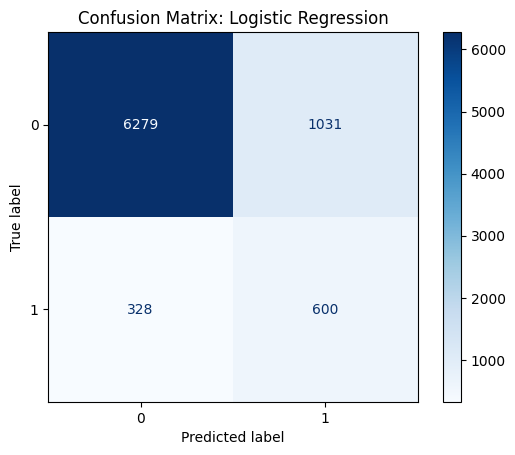

In [5]:
models = {'Logistic Regression': lr_model, 'Decision Tree': dt_model, 'Random Forest': rf_model}

for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    print(f"--- {name} ---")
    print(classification_report(y_test, preds))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}\n")

# Visualize Confusion Matrix for the best performing model
ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

### Interpretation & Communication

In [6]:
cat_encoder = rf_model.named_steps['preprocessor'].transformers_[1][1]
encoded_cat_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names = list(numeric_features) + list(encoded_cat_names)

importances = rf_model.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Features Driving Subscription Decisions:")
print(importance_df.head(10))

Top 10 Features Driving Subscription Decisions:
           Feature  Importance
0              age    0.134476
7        euribor3m    0.122232
1         campaign    0.077603
8      nr.employed    0.065061
4     emp.var.rate    0.050051
6    cons.conf.idx    0.029274
38     housing_yes    0.018684
36      housing_no    0.018646
5   cons.price.idx    0.018002
9       job_admin.    0.017610
